<a href="https://colab.research.google.com/github/Mayo-27-git/Major-Project/blob/main/DCGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

In [ ]:
import torch
import os
import random
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

class CelebAInpaintingDataset(Dataset):
    def __init__(self, root, transform, min_mask_ratio=0.2, max_mask_ratio=0.4, seed=42):
        self.image_paths = sorted([os.path.join(root, img) for img in os.listdir(root)
                                   if img.endswith('.jpg') or img.endswith('.png')])  # Sort images
        self.transform = transform
        self.min_mask_ratio = min_mask_ratio  # Min % of the image to be masked
        self.max_mask_ratio = max_mask_ratio  # Max % of the image to be masked
        self.seed = seed  # Set a seed for reproducibility

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")  # Load image

        if self.transform:
            image = self.transform(image)

        # Set random seed using index to ensure same mask per image
        random.seed(self.seed + idx)
        np.random.seed(self.seed + idx)
        torch.manual_seed(self.seed + idx)

        # Create a binary mask (1 = visible, 0 = missing)
        mask = torch.ones_like(image)
        h, w = image.shape[1], image.shape[2]

        # Random mask size between min_mask_ratio and max_mask_ratio
        mask_h = random.randint(int(h * self.min_mask_ratio), int(h * self.max_mask_ratio))
        mask_w = random.randint(int(w * self.min_mask_ratio), int(w * self.max_mask_ratio))

        # Random mask position
        top = random.randint(0, h - mask_h)
        left = random.randint(0, w - mask_w)

        # Apply mask
        mask[:, top:top + mask_h, left:left + mask_w] = 0
        masked_image = image * mask  # Apply the mask

        return masked_image, mask, image  # Return masked image, mask, and original image

# Define transformation
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize to match model input
    transforms.ToTensor(),  # Convert image to tensor
])

# Load dataset
dataset = CelebAInpaintingDataset(root="/kaggle/input/project/FINAL PROJECT/REAL IMAGES", transform=transform)

# Load DataLoader (No shuffle to maintain order)
dataloader = DataLoader(dataset, batch_size=64, shuffle=False)

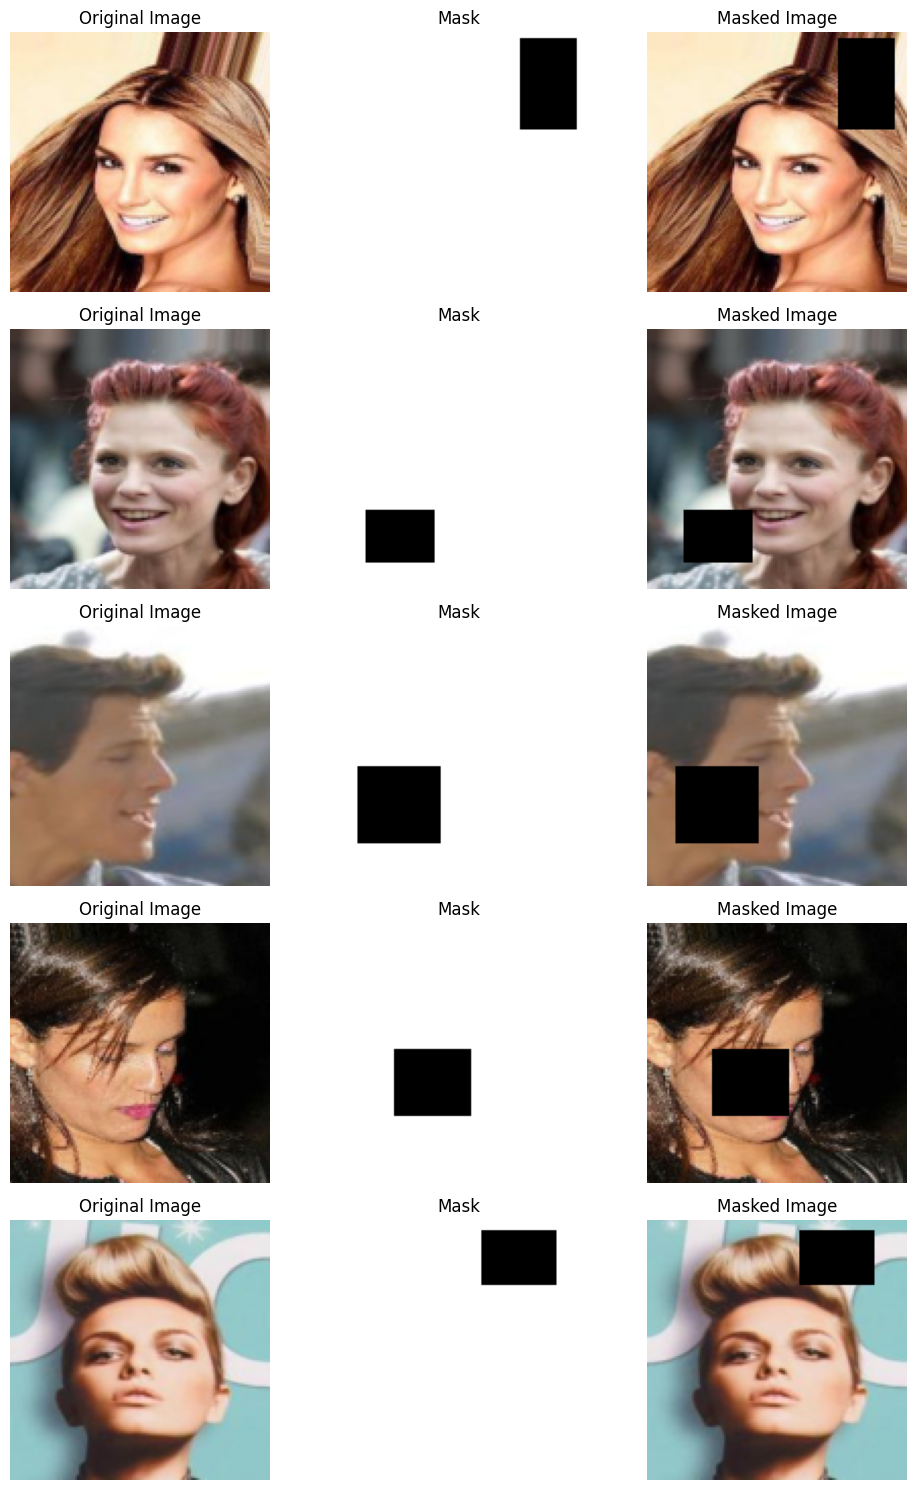

In [ ]:
import matplotlib.pyplot as plt

# Display 5 random images with their masks and masked versions
num_samples = 5
fig, axes = plt.subplots(num_samples, 3, figsize=(10, num_samples * 3))

for i in range(num_samples):
    masked_img, mask, real_img = dataset[i]  # Correct the order

    # Convert tensors to NumPy for visualization
    real_img_np = real_img.permute(1, 2, 0).numpy()
    mask_np = mask.permute(1, 2, 0).numpy()
    masked_img_np = masked_img.permute(1, 2, 0).numpy()

    # Display original image
    axes[i, 0].imshow(real_img_np)
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    # Display mask
    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title("Mask")
    axes[i, 1].axis("off")

    # Display masked image
    axes[i, 2].imshow(masked_img_np)
    axes[i, 2].set_title("Masked Image")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Define Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# 1️⃣ Define the Generator for Inpainting
# ------------------------------
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.main = nn.Sequential(
            nn.Conv2d(4, 64, 5, stride=1, padding=2),  # (Masked RGB + Mask Channel)
            nn.ReLU(),
            nn.Conv2d(64, 128, 5, stride=1, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 5, stride=1, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 3, 5, stride=1, padding=2),  # Output 3-channel image
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)


In [ ]:
# 2️⃣ Define the Discriminator
# ------------------------------
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),  # Flatten before FC layer
            nn.Linear(512 * 8 * 8, 1),  # Ensure output is (batch_size, 1)
            nn.Sigmoid()  # Output probability (0 to 1)
        )

    def forward(self, x):
        return self.model(x)


Epoch [1/100] | D Loss: 1.1901 | G Loss: 2.7801
Epoch [2/100] | D Loss: 1.1060 | G Loss: 2.4296
Epoch [3/100] | D Loss: 1.3279 | G Loss: 1.7571
Epoch [4/100] | D Loss: 1.2678 | G Loss: 1.6214
Epoch [5/100] | D Loss: 1.1876 | G Loss: 1.6911
Epoch [6/100] | D Loss: 1.2615 | G Loss: 1.6096
Epoch [7/100] | D Loss: 1.2756 | G Loss: 1.4608
Epoch [8/100] | D Loss: 1.1132 | G Loss: 1.6627
Epoch [9/100] | D Loss: 1.1324 | G Loss: 1.6323
Epoch [10/100] | D Loss: 1.1858 | G Loss: 1.6677
Epoch [11/100] | D Loss: 1.0944 | G Loss: 1.7756
Epoch [12/100] | D Loss: 1.1070 | G Loss: 1.6539
Epoch [13/100] | D Loss: 1.1713 | G Loss: 1.6442
Epoch [14/100] | D Loss: 1.1629 | G Loss: 1.7420
Epoch [15/100] | D Loss: 1.1618 | G Loss: 1.7154
Epoch [16/100] | D Loss: 1.1650 | G Loss: 1.6218
Epoch [17/100] | D Loss: 1.1602 | G Loss: 1.6166
Epoch [18/100] | D Loss: 1.1300 | G Loss: 1.5964
Epoch [19/100] | D Loss: 1.0781 | G Loss: 1.6350
Epoch [20/100] | D Loss: 1.0710 | G Loss: 1.6785
Epoch [21/100] | D Loss: 1.01

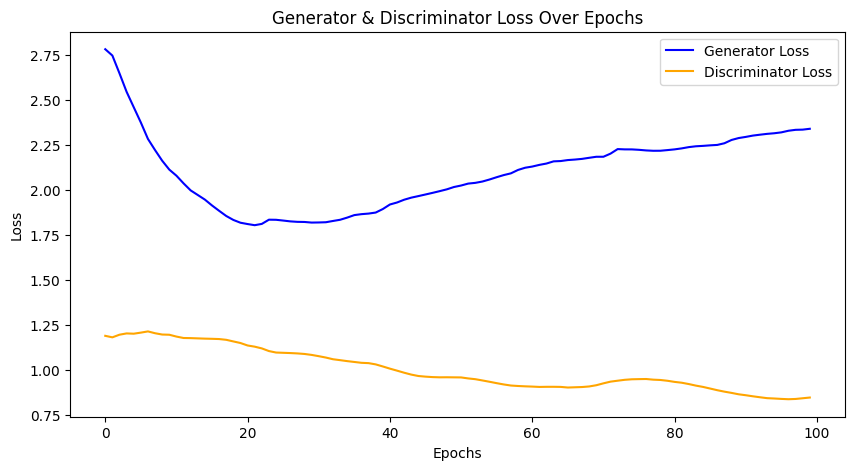

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.utils as vutils
import os

# Initialize Models
netG = Generator().to(device)
netD = Discriminator().to(device)

# Loss functions
criterion = nn.BCELoss()
reconstruction_loss = nn.L1Loss()

# Optimizers (Reduced Discriminator LR)
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=0.0001, betas=(0.5, 0.999))  # Lowered LR for better balance

# Store losses
g_losses = []
d_losses = []

# Training Parameters
num_epochs = 100
smooth_factor = 0.1  # Used for smoothing loss curves

# Training Loop
for epoch in range(num_epochs):
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    num_batches = len(dataloader)

    for i, (masked_image, mask, real_image) in enumerate(dataloader):
        masked_image = masked_image.to(device)
        mask = mask.to(device)
        real_image = real_image.to(device)

        # Label Smoothing (Prevents Discriminator Overconfidence)
        real_labels = (torch.ones(masked_image.size(0), 1) * 0.9).to(device)  # Instead of 1, use 0.9
        fake_labels = (torch.zeros(masked_image.size(0), 1) + 0.1).to(device)  # Instead of 0, use 0.1

        # Train Discriminator
        netD.zero_grad()
        real_output = netD(real_image)
        real_loss = criterion(real_output, real_labels)

        fake_image = netG(torch.cat((masked_image, mask[:, :1, :, :]), dim=1))
        fake_output = netD(fake_image.detach())  # Detach so generator gradients don’t flow to D
        fake_loss = criterion(fake_output, fake_labels)

        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizerD.step()

        # Train Generator
        netG.zero_grad()
        fake_output = netD(fake_image)
        g_loss = criterion(fake_output, real_labels) + reconstruction_loss(fake_image, real_image) * 10

        g_loss.backward()
        optimizerG.step()

        # Accumulate losses
        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()

    # Average loss per epoch (Smooth for better graphs)
    g_losses.append((1 - smooth_factor) * g_losses[-1] + smooth_factor * (epoch_g_loss / num_batches) if g_losses else epoch_g_loss / num_batches)
    d_losses.append((1 - smooth_factor) * d_losses[-1] + smooth_factor * (epoch_d_loss / num_batches) if d_losses else epoch_d_loss / num_batches)

    print(f"Epoch [{epoch+1}/{num_epochs}] | D Loss: {epoch_d_loss / num_batches:.4f} | G Loss: {epoch_g_loss / num_batches:.4f}")

    # Save Images Every 20 Epochs
    if epoch % 20 == 0:
        os.makedirs("output", exist_ok=True)
        vutils.save_image(fake_image, f"output/fake_epoch_{epoch}.png", normalize=True)

# Plot Losses
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss", color="blue")
plt.plot(d_losses, label="Discriminator Loss", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Generator & Discriminator Loss Over Epochs")
plt.show()


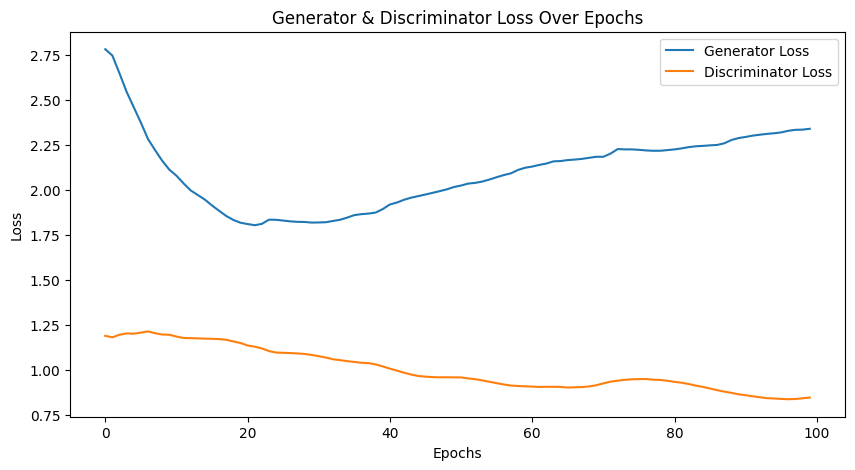

In [ ]:
# ------------------------------
# 6️⃣ Plot Loss Curves
# ------------------------------
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Generator & Discriminator Loss Over Epochs")
plt.show()

In [ ]:
# ------------------------------
# 6️⃣ Generate Inpainted Image (Fixed)
# ------------------------------
def inpaint_image(model, masked_image, mask):
    model.eval()
    with torch.no_grad():
        # Ensure the mask has 4 dimensions
        if mask.dim() == 3:  # If (C, H, W), add batch dimension
            mask = mask.unsqueeze(0)
        if masked_image.dim() == 3:  # If (C, H, W), add batch dimension
            masked_image = masked_image.unsqueeze(0)

        # Use only 1 channel from mask and concatenate
        input_image = torch.cat((masked_image, mask[:, :1, :, :]), dim=1).to(device)

        # Generate inpainted image
        output = model(input_image)

    return output.squeeze(0).cpu()  # Remove batch dimension for visualization


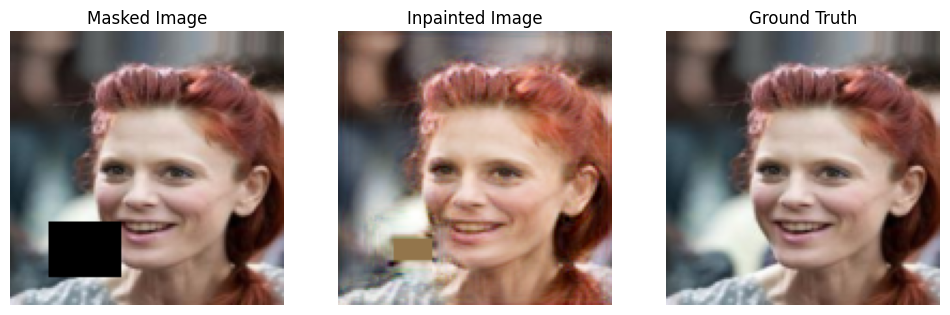

In [ ]:
# ------------------------------
# 7️⃣ Display Inpainted Image (Fixed)
# ------------------------------
import matplotlib.pyplot as plt

# Load a test image
test_img, test_mask, test_gt = dataset[1]  # (masked_image, mask, real_image)

# Ensure the test images have correct dimensions
test_img = test_img.to(device)
test_mask = test_mask.to(device)

# Generate the inpainted result
inpainted_result = inpaint_image(netG, test_img, test_mask)

# Convert tensors to numpy for visualization
masked_np = test_img.cpu().permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)
inpainted_np = inpainted_result.permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)
ground_truth_np = test_gt.cpu().permute(1, 2, 0).numpy()  # (C, H, W) -> (H, W, C)

# Display images
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Masked Image")
plt.imshow(masked_np)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Inpainted Image")
plt.imshow(inpainted_np)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Ground Truth")
plt.imshow(ground_truth_np)
plt.axis("off")

plt.show()


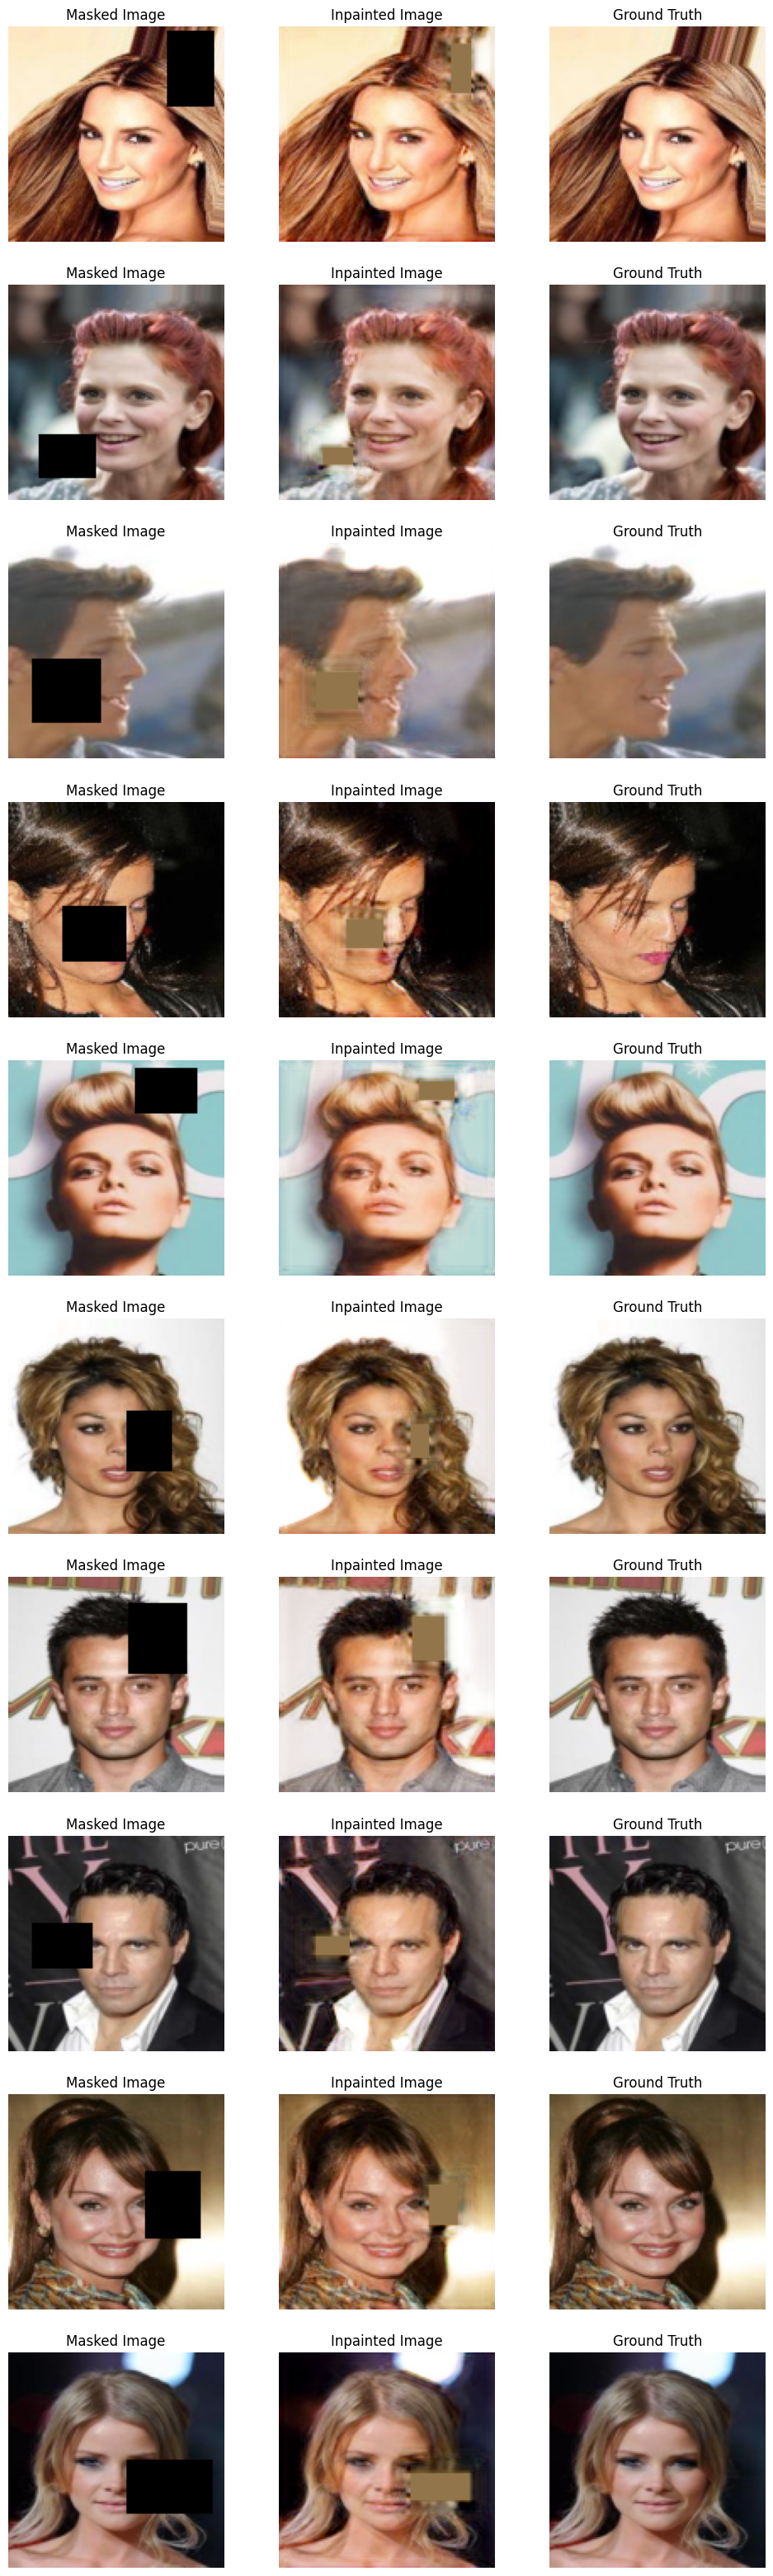

In [ ]:
import matplotlib.pyplot as plt

# Number of test images to display
num_images = 10

plt.figure(figsize=(12, 4 * num_images))  # Adjust figure size based on number of images

for i in range(num_images):
    # Load a test image
    test_img, test_mask, test_gt = dataset[i]  # (masked_image, mask, real_image)

    # Ensure the test images have correct dimensions
    test_img = test_img.to(device)
    test_mask = test_mask.to(device)

    # Generate the inpainted result
    inpainted_result = inpaint_image(netG, test_img, test_mask)

    # Convert tensors to numpy for visualization
    masked_np = test_img.cpu().permute(1, 2, 0).numpy()
    inpainted_np = inpainted_result.permute(1, 2, 0).numpy()
    ground_truth_np = test_gt.cpu().permute(1, 2, 0).numpy()

    # Display images in a row
    plt.subplot(num_images, 3, i * 3 + 1)
    plt.title("Masked Image")
    plt.imshow(masked_np)
    plt.axis("off")

    plt.subplot(num_images, 3, i * 3 + 2)
    plt.title("Inpainted Image")
    plt.imshow(inpainted_np)
    plt.axis("off")

    plt.subplot(num_images, 3, i * 3 + 3)
    plt.title("Ground Truth")
    plt.imshow(ground_truth_np)
    plt.axis("off")

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import shutil
import os

# Define Kaggle working directory
save_dir = "/kaggle/working/lala"

# Create directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Number of test images to display and save
num_images = 10

plt.figure(figsize=(12, 4 * num_images))  # Adjust figure size

for i in range(num_images):
    # Load a test image
    test_img, test_mask, test_gt = dataset[i]  # (masked_image, mask, real_image)

    # Ensure the test images have correct dimensions
    test_img = test_img.to(device)
    test_mask = test_mask.to(device)

    # Generate the inpainted result
    inpainted_result = inpaint_image(netG, test_img, test_mask)

    # Convert tensors to numpy for visualization
    masked_np = test_img.cpu().permute(1, 2, 0).numpy()
    inpainted_np = inpainted_result.permute(1, 2, 0).cpu().numpy()
    ground_truth_np = test_gt.cpu().permute(1, 2, 0).numpy()

    # Convert to 8-bit image format (0-255) and save using PIL
    inpainted_img = (np.clip(inpainted_np, 0, 1) * 255).astype(np.uint8)
    inpainted_pil = Image.fromarray(inpainted_img)

    # Save image in Kaggle directory
    save_path = os.path.join(save_dir, f"inpainted_{i}.jpg")
    inpainted_pil.save(save_path, format="JPEG", quality=95)  # Save as JPG

    # Display images
    plt.subplot(num_images, 3, i * 3 + 1)
    plt.title("Masked Image")
    plt.imshow(masked_np)
    plt.axis("off")

    plt.subplot(num_images, 3, i * 3 + 2)
    plt.title("Inpainted Image")
    plt.imshow(inpainted_np)
    plt.axis("off")

    plt.subplot(num_images, 3, i * 3 + 3)
    plt.title("Ground Truth")
    plt.imshow(ground_truth_np)
    plt.axis("off")

plt.show()

print(f"Saved inpainted images in {save_dir}")


In [ ]:
import shutil

# Create a ZIP file of all saved inpainted images
shutil.make_archive("/kaggle/working/Inpainted_images", "zip", "")

print("Zipped all images as inpainted_images.zip")


Zipped all images as inpainted_images.zip


In [ ]:

# Initialize model, optimizers, and loss functions
generator = Generator().to(device)  # Define your generator model
discriminator = Discriminator().to(device)  # Define your discriminator model

In [ ]:
import torch

# Save model (assuming your generator is called 'generator')
torch.save(generator.state_dict(), "/kaggle/working/generator.pth")

# Save discriminator (if needed)
torch.save(discriminator.state_dict(), "/kaggle/working/discriminator.pth")


In [ ]:
import os
import shutil
from natsort import natsorted
import zipfile

# Define input and output directories
input_folder = "/kaggle/input/new-img"  # Change this to your dataset folder
output_folder = "/kaggle/working/sorted-images"

# Create an output folder
os.makedirs(output_folder, exist_ok=True)

# Get the list of files and sort them numerically
files = os.listdir(input_folder)
sorted_files = natsorted(files)

# Copy files in sorted order to the new directory
for file in sorted_files:
    shutil.copy(os.path.join(input_folder, file), os.path.join(output_folder, file))

print("Files sorted and copied to:", output_folder)


Files sorted and copied to: /kaggle/working/sorted-images


NOTEPAD LE CODE

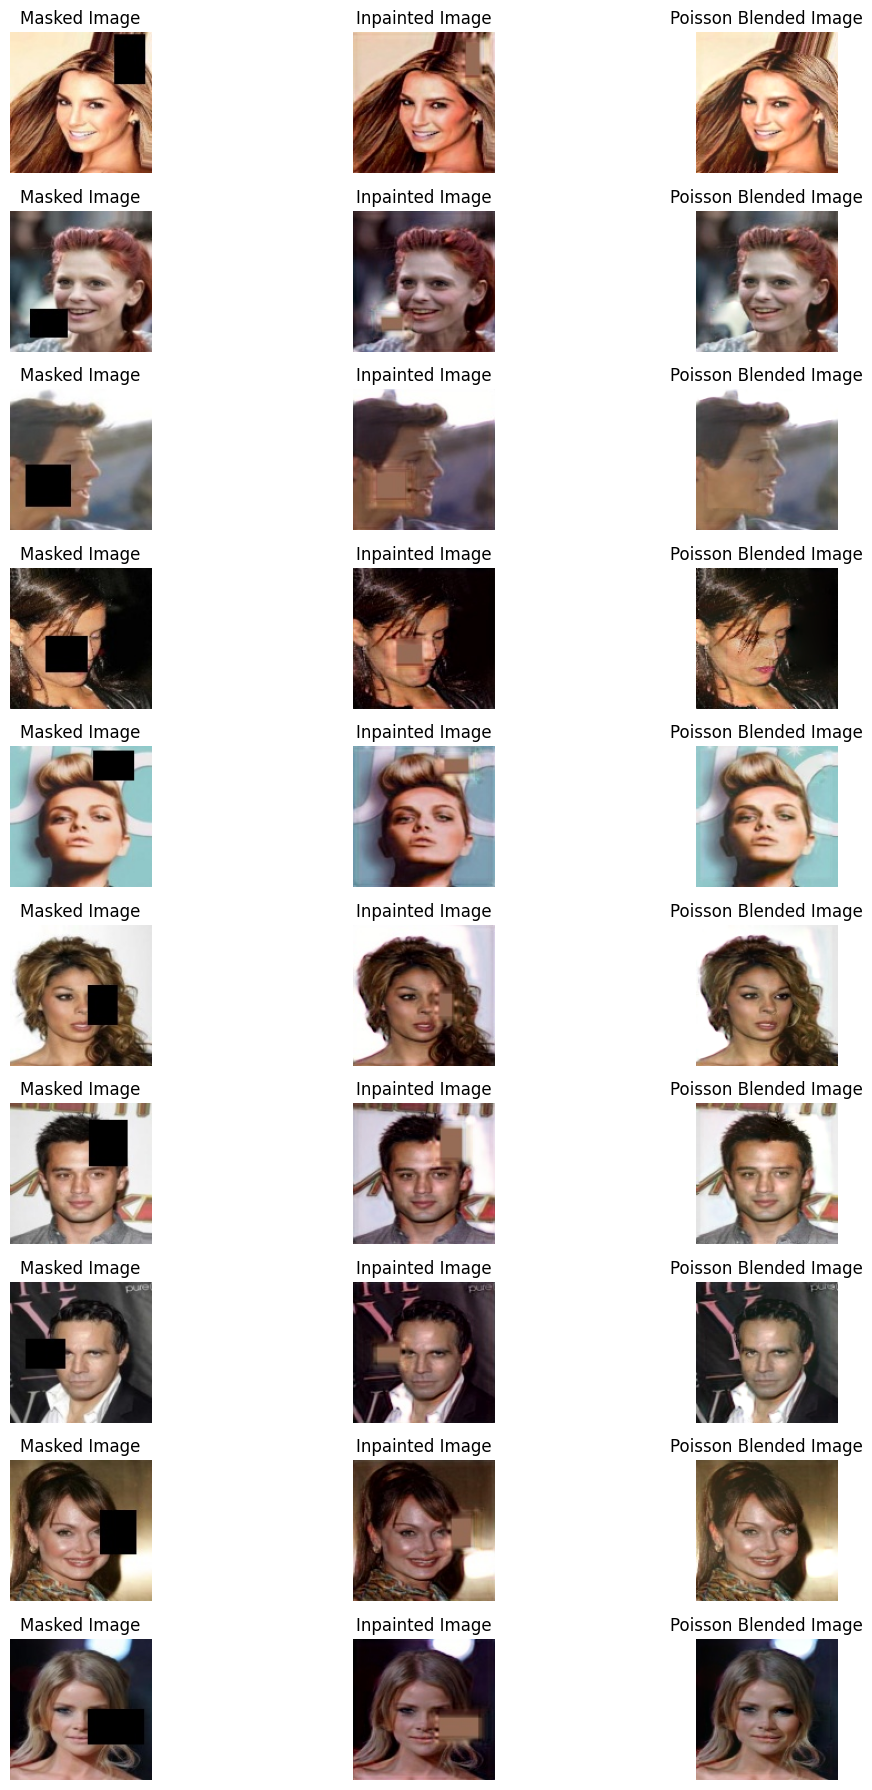

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def resize_images(base_img, *other_imgs):
    """
    Resizes all images in other_imgs to match the dimensions of base_img.
    """
    target_size = (base_img.shape[1], base_img.shape[0])  # (width, height)
    return [cv2.resize(img, target_size) for img in other_imgs]

def poisson_blend(ground_truth_np, mask_np, inpainted_np):
    """
    Performs Poisson blending using the inpainted image as the source
    and the original image as the destination.
    """
    # Convert images to uint8 if not already
    ground_truth_np = (ground_truth_np * 255).astype(np.uint8) if ground_truth_np.max() <= 1 else ground_truth_np
    inpainted_np = (inpainted_np * 255).astype(np.uint8) if inpainted_np.max() <= 1 else inpainted_np
    mask_np = (mask_np * 255).astype(np.uint8) if mask_np.max() <= 1 else mask_np

    # Ensure mask is a single-channel binary image
    if len(mask_np.shape) == 3:
        mask_np = cv2.cvtColor(mask_np, cv2.COLOR_BGR2GRAY)

    mask_np[mask_np > 0] = 255  # Convert to binary mask (0 or 255)

    # Resize images to ensure they are the same size
    ground_truth_np, inpainted_np, mask_np = resize_images(inpainted_np, ground_truth_np, inpainted_np, mask_np)

    # Find the center of the masked region
    mask_indices = np.argwhere(mask_np > 0)
    if len(mask_indices) == 0:
        print("Warning: No mask detected! Skipping blending.")
        return inpainted_np  # Return inpainted image if no mask found

    y_min, x_min = mask_indices.min(axis=0)
    y_max, x_max = mask_indices.max(axis=0)
    center = ((x_min + x_max) // 2, (y_min + y_max) // 2)

    # Perform Poisson blending
    blended_image = cv2.seamlessClone(inpainted_np, ground_truth_np, mask_np, center, cv2.NORMAL_CLONE)

    # Ensure blended image has the same size as masked and inpainted image
    blended_image = cv2.resize(blended_image, (inpainted_np.shape[1], inpainted_np.shape[0]))

    return blended_image

# ---- Dataset Paths ----
masked_folder = "/kaggle/input/masked-img"
inpainted_folder = "/kaggle/input/inpainted-new"
ground_truth_folder = "/kaggle/input/project/FINAL PROJECT/REAL IMAGES"

# Get sorted filenames
masked_files = sorted(os.listdir(masked_folder))[:10]  # First 5 masked images
inpainted_files = sorted(os.listdir(inpainted_folder))[:10]  # First 5 inpainted images
ground_truth_files = sorted(os.listdir(ground_truth_folder))[:10]  # First 5 real images

# ---- Visualization ----
  # 5 rows, 3 columns (Masked, Inpainted, Blended)
fig, axes = plt.subplots(10, 3, figsize=(12, 18))

for i, (m_file, i_file, g_file) in enumerate(zip(masked_files, inpainted_files, ground_truth_files)):
    masked_img = cv2.imread(os.path.join(masked_folder, m_file))
    inpainted_img = cv2.imread(os.path.join(inpainted_folder, i_file))
    ground_truth_img = cv2.imread(os.path.join(ground_truth_folder, g_file))

    # Convert images from BGR to RGB for correct display
    masked_img = cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB)
    inpainted_img = cv2.cvtColor(inpainted_img, cv2.COLOR_BGR2RGB)
    ground_truth_img = cv2.cvtColor(ground_truth_img, cv2.COLOR_BGR2RGB)

    # Ensure all images are the same size
    masked_img, inpainted_img = resize_images(inpainted_img, masked_img, inpainted_img)

    # Perform Poisson blending
    blended_img = poisson_blend(ground_truth_img, masked_img, inpainted_img)

    # Display images
    axes[i, 0].imshow(masked_img)
    axes[i, 0].set_title("Masked Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(inpainted_img)
    axes[i, 1].set_title("Inpainted Image")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(blended_img)
    axes[i, 2].set_title("Poisson Blended Image")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()


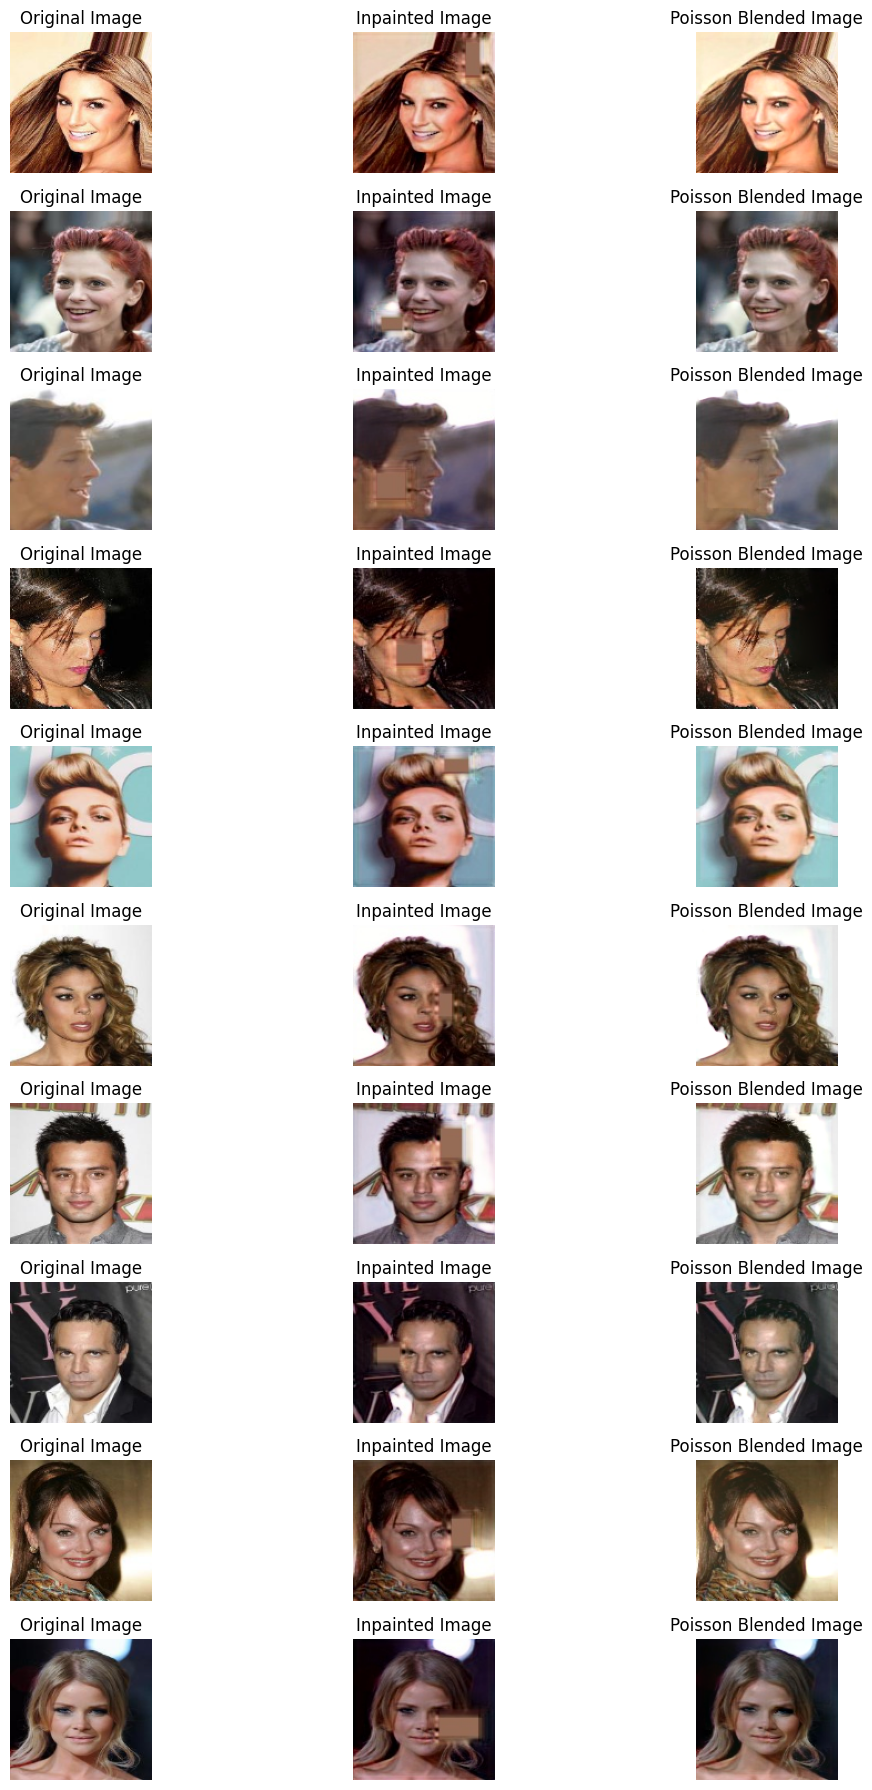

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def resize_images(base_img, *other_imgs):
    """
    Resizes all images in other_imgs to match the dimensions of base_img.
    """
    target_size = (base_img.shape[1], base_img.shape[0])  # (width, height)
    return [cv2.resize(img, target_size) for img in other_imgs]

def poisson_blend(ground_truth_np, mask_np, inpainted_np):
    """
    Performs Poisson blending using the inpainted image as the source
    and the original image as the destination.
    """
    # Convert images to uint8 if not already
    ground_truth_np = (ground_truth_np * 255).astype(np.uint8) if ground_truth_np.max() <= 1 else ground_truth_np
    inpainted_np = (inpainted_np * 255).astype(np.uint8) if inpainted_np.max() <= 1 else inpainted_np
    mask_np = (mask_np * 255).astype(np.uint8) if mask_np.max() <= 1 else mask_np

    # Ensure mask is a single-channel binary image
    if len(mask_np.shape) == 3:
        mask_np = cv2.cvtColor(mask_np, cv2.COLOR_BGR2GRAY)

    mask_np[mask_np > 0] = 255  # Convert to binary mask (0 or 255)

    # Resize images to ensure they are the same size
    ground_truth_np, inpainted_np, mask_np = resize_images(inpainted_np, ground_truth_np, inpainted_np, mask_np)

    # Find the center of the masked region
    mask_indices = np.argwhere(mask_np > 0)
    if len(mask_indices) == 0:
        print("Warning: No mask detected! Skipping blending.")
        return inpainted_np  # Return inpainted image if no mask found

    y_min, x_min = mask_indices.min(axis=0)
    y_max, x_max = mask_indices.max(axis=0)
    center = ((x_min + x_max) // 2, (y_min + y_max) // 2)

    # Perform Poisson blending
    blended_image = cv2.seamlessClone(inpainted_np, ground_truth_np, mask_np, center, cv2.NORMAL_CLONE)

    # Ensure blended image has the same size as inpainted image
    blended_image = cv2.resize(blended_image, (inpainted_np.shape[1], inpainted_np.shape[0]))

    return blended_image

# ---- Dataset Paths ----
masked_folder = "/kaggle/input/masked-img"
inpainted_folder = "/kaggle/input/inpainted-new"
ground_truth_folder = "/kaggle/input/project/FINAL PROJECT/REAL IMAGES"

# Get sorted filenames
masked_files = sorted(os.listdir(masked_folder))[:10]  # First 5 masked images
inpainted_files = sorted(os.listdir(inpainted_folder))[:10]  # First 5 inpainted images
ground_truth_files = sorted(os.listdir(ground_truth_folder))[:10]  # First 5 real images

# ---- Visualization ----
fig, axes = plt.subplots(10, 3, figsize=(12, 18))  # 5 rows, 3 columns (Ground Truth, Inpainted, Blended)

for i, (m_file, i_file, g_file) in enumerate(zip(masked_files, inpainted_files, ground_truth_files)):
    masked_img = cv2.imread(os.path.join(masked_folder, m_file))  # Mask is used for blending
    inpainted_img = cv2.imread(os.path.join(inpainted_folder, i_file))
    ground_truth_img = cv2.imread(os.path.join(ground_truth_folder, g_file))

    # Convert images from BGR to RGB for correct display
    inpainted_img = cv2.cvtColor(inpainted_img, cv2.COLOR_BGR2RGB)
    ground_truth_img = cv2.cvtColor(ground_truth_img, cv2.COLOR_BGR2RGB)

    # Ensure all images are the same size
    ground_truth_img, inpainted_img = resize_images(inpainted_img, ground_truth_img, inpainted_img)

    # Perform Poisson blending
    blended_img = poisson_blend(ground_truth_img, masked_img, inpainted_img)

    # Display images
    axes[i, 0].imshow(ground_truth_img)
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(inpainted_img)
    axes[i, 1].set_title("Inpainted Image")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(blended_img)
    axes[i, 2].set_title("Poisson Blended Image")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
!pip install scikit-image


In [ ]:
import torch
import numpy as np
import torchvision.transforms as transforms
from skimage.metrics import peak_signal_noise_ratio as psnr

# Convert tensor to PIL image
to_pil = transforms.ToPILImage()

def calculate_psnr(inpainted_tensor, ground_truth_tensor):
    """
    Calculate PSNR between inpainted image and ground truth.

    Args:
        inpainted_tensor (Tensor): Generated inpainted image (C, H, W)
        ground_truth_tensor (Tensor): Original ground truth image (C, H, W)

    Returns:
        psnr_value (float): PSNR score
    """
    # Convert tensors to NumPy arrays (H, W, C) format
    inpainted_np = np.array(to_pil(inpainted_tensor)).astype(np.float32)
    ground_truth_np = np.array(to_pil(ground_truth_tensor)).astype(np.float32)

    # Compute PSNR
    return psnr(ground_truth_np, inpainted_np, data_range=255)

# Example Usage
if __name__ == "__main__":
    # Dummy tensors (3,128,128) with values between 0 and 1
    fake_image = torch.rand(3, 128, 128)  # Inpainted Image
    real_image = torch.rand(3, 128, 128)  # Ground Truth Image

    psnr_value = calculate_psnr(fake_image, real_image)
    print(f"PSNR Value: {psnr_value:.2f} dB")


PSNR Value: 7.77 dB


In [ ]:
import torch
import numpy as np
import torchvision.transforms as transforms
from skimage.metrics import structural_similarity as ssim

# Convert tensor to PIL image
to_pil = transforms.ToPILImage()

def calculate_ssim(inpainted_tensor, ground_truth_tensor):
    """
    Calculate SSIM between inpainted image and ground truth.

    Args:
        inpainted_tensor (Tensor): Generated inpainted image (C, H, W)
        ground_truth_tensor (Tensor): Original ground truth image (C, H, W)

    Returns:
        ssim_value (float): SSIM score
    """
    # Convert tensors to NumPy arrays (H, W, C) format
    inpainted_np = np.array(to_pil(inpainted_tensor)).astype(np.float32)
    ground_truth_np = np.array(to_pil(ground_truth_tensor)).astype(np.float32)

    # Convert to grayscale (for SSIM calculation)
    inpainted_gray = np.dot(inpainted_np[..., :3], [0.299, 0.587, 0.114])
    ground_truth_gray = np.dot(ground_truth_np[..., :3], [0.299, 0.587, 0.114])

    # Compute SSIM
    return ssim(ground_truth_gray, inpainted_gray, data_range=255)

# Example Usage
if __name__ == "__main__":
    # Dummy tensors (3,128,128) with values between 0 and 1
    fake_image = torch.rand(3, 128, 128)  # Inpainted Image
    real_image = torch.rand(3, 128, 128)  # Ground Truth Image

    ssim_value = calculate_ssim(fake_image, real_image)
    print(f"SSIM Value: {ssim_value:.4f}")


SSIM Value: 0.0053


In [ ]:
pip install lpips


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
import lpips  # Learned Perceptual Image Patch Similarity
import torchvision.transforms as transforms

# Load LPIPS model (default: VGG-based perceptual loss)
lpips_model = lpips.LPIPS(net='vgg').to("cuda" if torch.cuda.is_available() else "cpu")

# Transform to match LPIPS input format
def preprocess_image(image_tensor):
    """
    Prepares an image tensor for LPIPS calculation.

    Args:
        image_tensor (Tensor): Image tensor of shape (C, H, W), values in [0, 1]

    Returns:
        Tensor: Normalized tensor suitable for LPIPS input
    """
    return (image_tensor * 2) - 1  # Normalize from [0,1] → [-1,1]

def calculate_lpips(inpainted_tensor, ground_truth_tensor):
    """
    Compute LPIPS distance between two images.

    Args:
        inpainted_tensor (Tensor): Generated inpainted image (C, H, W)
        ground_truth_tensor (Tensor): Original ground truth image (C, H, W)

    Returns:
        lpips_value (float): LPIPS score (lower is better)
    """
    # Ensure input is on the same device as LPIPS model
    device = "cuda" if torch.cuda.is_available() else "cpu"
    inpainted_tensor = preprocess_image(inpainted_tensor).unsqueeze(0).to(device)  # Add batch dim
    ground_truth_tensor = preprocess_image(ground_truth_tensor).unsqueeze(0).to(device)

    # Compute LPIPS distance
    lpips_score = lpips_model(inpainted_tensor, ground_truth_tensor)

    return lpips_score.item()

# Example Usage
if __name__ == "__main__":
    # Dummy tensors (C, H, W) with values in [0,1]
    fake_image = torch.rand(3, 128, 128)  # Inpainted Image
    real_image = torch.rand(3, 128, 128)  # Ground Truth Image

    lpips_value = calculate_lpips(fake_image, real_image)
    print(f"LPIPS Score: {lpips_value:.4f}")


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 215MB/s] 


Loading model from: /usr/local/lib/python3.10/dist-packages/lpips/weights/v0.1/vgg.pth
LPIPS Score: 0.3620


/usr/local/lib/python3.10/dist-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, map_location='cpu'), st